## define parameters 

In [2]:
from pyspark.sql.types import *
from pyspark.sql.functions import *
from delta.tables import *
import time

# silver and gold tables
SILVER_TABLE = "lh_sales.dbo.sales_silver"
DIMDATE_TABLE = "lh_sales.dbo.dimdate_gold"
DIMCUSTOMER_TABLE = "lh_sales.dbo.dimcustomer_gold"
DIMPRODUCT_TABLE = "lh_sales.dbo.dimproduct_gold"
FACTSALES_TABLE = "lh_sales.dbo.factsales_gold"

# raw data
BRONZE_PATH = "Files/bronze/*.csv"

# lineage parameters
BATCH_ID = lit(str(int(time.time())))
SOURCE_SYSTEM = lit("OrdersCSV")
LOAD_TS = current_timestamp()

StatementMeta(, 94fbd8a0-42d6-4030-bc06-448fc1ae6f08, 4, Finished, Available, Finished)

## bronze to silver table

In [3]:
# bronze schema
orderSchema = StructType([
    StructField("SalesOrderNumber", StringType()),
    StructField("SalesOrderLineNumber", IntegerType()),
    StructField("OrderDate", DateType()),
    StructField("CustomerName", StringType()),
    StructField("Email", StringType()),
    StructField("Item", StringType()),
    StructField("Quantity", IntegerType()),
    StructField("UnitPrice", FloatType()),
    StructField("Tax", FloatType())
])

# load bronze
df_bronze = spark.read.format("csv") \
    .option("header", "false") \
    .schema(orderSchema) \
    .load(BRONZE_PATH)

# add audit parameters and handle CustomerName
df_bronze = df_bronze.withColumn("FileName", input_file_name()) \
    .withColumn("IsFlagged", when(col("OrderDate") < to_date(lit("2019-08-01")), lit(True)).otherwise(lit(False))) \
    .withColumn("CreatedTS", LOAD_TS) \
    .withColumn("ModifiedTS", LOAD_TS) \
    .withColumn("BatchID", BATCH_ID) \
    .withColumn("SourceSystem", SOURCE_SYSTEM)\
    .withColumn("CustomerName", when(col("CustomerName").isNull() | (col("CustomerName") == ""), lit("Unknown")).otherwise(col("CustomerName")))

# silver table
DeltaTable.createIfNotExists(spark) \
    .tableName(SILVER_TABLE) \
    .addColumn("SalesOrderNumber", StringType()) \
    .addColumn("SalesOrderLineNumber", IntegerType()) \
    .addColumn("OrderDate", DateType()) \
    .addColumn("CustomerName", StringType()) \
    .addColumn("Email", StringType()) \
    .addColumn("Item", StringType()) \
    .addColumn("Quantity", IntegerType()) \
    .addColumn("UnitPrice", FloatType()) \
    .addColumn("Tax", FloatType()) \
    .addColumn("FileName", StringType()) \
    .addColumn("IsFlagged", BooleanType()) \
    .addColumn("CreatedTS", TimestampType()) \
    .addColumn("ModifiedTS", TimestampType()) \
    .addColumn("BatchID", StringType()) \
    .addColumn("SourceSystem", StringType()) \
    .execute()

# merge into silver
silver_dt = DeltaTable.forName(spark, SILVER_TABLE)
merge_condition = """
silver.SalesOrderNumber = updates.SalesOrderNumber AND
silver.SalesOrderLineNumber = updates.SalesOrderLineNumber AND
silver.OrderDate = updates.OrderDate AND
silver.CustomerName = updates.CustomerName AND
silver.Item = updates.Item
"""

silver_dt.alias("silver").merge(
    df_bronze.alias("updates"),
    merge_condition
).whenMatchedUpdate(set={
    "ModifiedTS": "updates.ModifiedTS",
    "BatchID": "updates.BatchID"
}).whenNotMatchedInsert(values={
    "SalesOrderNumber": "updates.SalesOrderNumber",
    "SalesOrderLineNumber": "updates.SalesOrderLineNumber",
    "OrderDate": "updates.OrderDate",
    "CustomerName": "updates.CustomerName",
    "Email": "updates.Email",
    "Item": "updates.Item",
    "Quantity": "updates.Quantity",
    "UnitPrice": "updates.UnitPrice",
    "Tax": "updates.Tax",
    "FileName": "updates.FileName",
    "IsFlagged": "updates.IsFlagged",
    "CreatedTS": "updates.CreatedTS",
    "ModifiedTS": "updates.ModifiedTS",
    "BatchID": "updates.BatchID",
    "SourceSystem": "updates.SourceSystem"
}).execute()

print("Silver row count:", spark.read.table(SILVER_TABLE).count())

StatementMeta(, 94fbd8a0-42d6-4030-bc06-448fc1ae6f08, 5, Finished, Available, Finished)

Silver row count: 32718


## silver to date dimension

In [5]:
# silver to gold dimensions
DeltaTable.createIfNotExists(spark) \
    .tableName(DIMDATE_TABLE) \
    .addColumn("OrderDate", DateType()) \
    .addColumn("Day", IntegerType()) \
    .addColumn("Month", IntegerType()) \
    .addColumn("Year", IntegerType()) \
    .addColumn("mmmyyyy", StringType()) \
    .addColumn("yyyymm", StringType()) \
    .execute()

# date dimension
df_dimdate = spark.read.table(SILVER_TABLE).dropDuplicates(["OrderDate"]).select(
    col("OrderDate"),
    dayofmonth("OrderDate").alias("Day"),
    month("OrderDate").alias("Month"),
    year("OrderDate").alias("Year"),
    date_format(col("OrderDate"), "MMM-yyyy").alias("mmmyyyy"),
    date_format(col("OrderDate"), "yyyyMM").alias("yyyymm")
)

DeltaTable.forName(spark, DIMDATE_TABLE).alias("gold").merge(
    df_dimdate.alias("updates"),
    "gold.OrderDate = updates.OrderDate"
).whenMatchedUpdate(set={}).whenNotMatchedInsert(values={
    "OrderDate": "updates.OrderDate",
    "Day": "updates.Day",
    "Month": "updates.Month",
    "Year": "updates.Year",
    "mmmyyyy": "updates.mmmyyyy",
    "yyyymm": "updates.yyyymm"
}).execute()


StatementMeta(, 94fbd8a0-42d6-4030-bc06-448fc1ae6f08, 7, Finished, Available, Finished)

## silver to customer dimension

In [6]:
# customer dimension
DeltaTable.createIfNotExists(spark) \
    .tableName(DIMCUSTOMER_TABLE) \
    .addColumn("CustomerName", StringType()) \
    .addColumn("Email", StringType()) \
    .addColumn("First", StringType()) \
    .addColumn("Last", StringType()) \
    .addColumn("CustomerID", StringType()) \
    .execute()

df_dimcust = spark.read.table(SILVER_TABLE).dropDuplicates(["CustomerName","Email"]).select(
    col("CustomerName"),
    col("Email"),
    split(col("CustomerName"), " ").getItem(0).alias("First"),
    split(col("CustomerName"), " ").getItem(1).alias("Last")
).withColumn("CustomerID", sha2(concat_ws("||", col("CustomerName"), col("Email")), 256))

DeltaTable.forName(spark, DIMCUSTOMER_TABLE).alias("gold").merge(
    df_dimcust.alias("updates"),
    "gold.CustomerID = updates.CustomerID"
).whenMatchedUpdate(set={
    "First": "updates.First",
    "Last": "updates.Last"
}).whenNotMatchedInsert(values={
    "CustomerName": "updates.CustomerName",
    "Email": "updates.Email",
    "First": "updates.First",
    "Last": "updates.Last",
    "CustomerID": "updates.CustomerID"
}).execute()


StatementMeta(, 94fbd8a0-42d6-4030-bc06-448fc1ae6f08, 8, Finished, Available, Finished)

## silver to product dimension

In [7]:
# product dimension
DeltaTable.createIfNotExists(spark) \
    .tableName(DIMPRODUCT_TABLE) \
    .addColumn("ItemName", StringType()) \
    .addColumn("ItemInfo", StringType()) \
    .addColumn("ItemID", StringType()) \
    .execute()

df_dimprod = spark.read.table(SILVER_TABLE).dropDuplicates(["Item"]).select(
    split(col("Item"), ", ").getItem(0).alias("ItemName"),
    when(
        (split(col("Item"), ", ").getItem(1).isNull()) | (split(col("Item"), ", ").getItem(1) == ""),
        lit("")
    ).otherwise(split(col("Item"), ", ").getItem(1)).alias("ItemInfo")
).withColumn("ItemID", sha2(concat_ws("||", col("ItemName"), col("ItemInfo")), 256))

DeltaTable.forName(spark, DIMPRODUCT_TABLE).alias("gold").merge(
    df_dimprod.alias("updates"),
    "gold.ItemID = updates.ItemID"
).whenMatchedUpdate(set={
    "ItemName": "updates.ItemName",
    "ItemInfo": "updates.ItemInfo"
}).whenNotMatchedInsert(values={
    "ItemName": "updates.ItemName",
    "ItemInfo": "updates.ItemInfo",
    "ItemID": "updates.ItemID"
}).execute()

StatementMeta(, 94fbd8a0-42d6-4030-bc06-448fc1ae6f08, 9, Finished, Available, Finished)

## sales fact table from customer and product dimension table

In [9]:
# sales fact table
DeltaTable.createIfNotExists(spark) \
    .tableName(FACTSALES_TABLE) \
    .addColumn("CustomerID", StringType()) \
    .addColumn("ItemID", StringType()) \
    .addColumn("OrderDate", DateType()) \
    .addColumn("Quantity", IntegerType()) \
    .addColumn("UnitPrice", FloatType()) \
    .addColumn("Tax", FloatType()) \
    .addColumn("TotalAmount", FloatType()) \
    .addColumn("Year", IntegerType()) \
    .addColumn("BatchID", StringType()) \
    .addColumn("SourceSystem", StringType()) \
    .execute()

# join dimcust and dimprod for factsales
df_dimcust = spark.read.table(DIMCUSTOMER_TABLE).select("CustomerID", "CustomerName", "Email")
df_dimprod = spark.read.table(DIMPRODUCT_TABLE).select("ItemID", "ItemName", "ItemInfo")

df_silver_enriched = spark.read.table(SILVER_TABLE) \
    .withColumn("ItemName", split(col("Item"), ", ").getItem(0)) \
    .withColumn("ItemInfo", when(
        (split(col("Item"), ", ").getItem(1).isNull()) | (split(col("Item"), ", ").getItem(1) == ""),
        lit("")
    ).otherwise(split(col("Item"), ", ").getItem(1))) \
    .withColumn("CustomerID", sha2(concat_ws("||", col("CustomerName"), col("Email")), 256)) \
    .withColumn("ItemID", sha2(concat_ws("||", col("ItemName"), col("ItemInfo")), 256))

df_fact = df_silver_enriched.alias("s").join(
    df_dimcust.alias("c"), col("s.CustomerID") == col("c.CustomerID"), "left"
).join(
    df_dimprod.alias("p"), col("s.ItemID") == col("p.ItemID"), "left"
).select(
    col("s.CustomerID"),
    col("s.ItemID"),
    col("s.OrderDate"),
    col("s.Quantity"),
    col("s.UnitPrice"),
    col("s.Tax"),
    (col("s.Quantity") * (col("s.UnitPrice") + col("s.Tax"))).alias("TotalAmount"),
    year(col("s.OrderDate")).alias("Year"),
    col("s.BatchID"),
    col("s.SourceSystem")
)

df_fact_valid = df_fact.filter(col("CustomerID").isNotNull() & col("ItemID").isNotNull())

fact_dt = DeltaTable.forName(spark, FACTSALES_TABLE)
fact_dt.alias("gold").merge(
    df_fact_valid.alias("updates"),
    "gold.OrderDate = updates.OrderDate AND gold.CustomerID = updates.CustomerID AND gold.ItemID = updates.ItemID"
).whenMatchedUpdate(set={
    "Quantity": "updates.Quantity",
    "UnitPrice": "updates.UnitPrice",
    "Tax": "updates.Tax",
    "TotalAmount": "updates.TotalAmount",
    "Year": "updates.Year",
    "BatchID": "updates.BatchID",
    "SourceSystem": "updates.SourceSystem"
}).whenNotMatchedInsert(values={
    "CustomerID": "updates.CustomerID",
    "ItemID": "updates.ItemID",
    "OrderDate": "updates.OrderDate",
    "Quantity": "updates.Quantity",
    "UnitPrice": "updates.UnitPrice",
    "Tax": "updates.Tax",
    "TotalAmount": "updates.TotalAmount",
    "Year": "updates.Year",
    "BatchID": "updates.BatchID",
    "SourceSystem": "updates.SourceSystem"
}).execute()

# validation
fact_count = spark.read.table(FACTSALES_TABLE).count()
missing_keys = df_fact.filter(col("CustomerID").isNull() | col("ItemID").isNull()).count()

print(f"Fact rows: {fact_count} | Rows with missing keys (excluded): {missing_keys}")

StatementMeta(, 94fbd8a0-42d6-4030-bc06-448fc1ae6f08, 11, Finished, Available, Finished)

Fact rows: 32718 | Rows with missing keys (excluded): 0


## compact files for query performance

In [11]:
# compact for query performance
spark.sql(f"OPTIMIZE {SILVER_TABLE}")
spark.sql(f"OPTIMIZE {DIMDATE_TABLE}")
spark.sql(f"OPTIMIZE {DIMCUSTOMER_TABLE}")
spark.sql(f"OPTIMIZE {DIMPRODUCT_TABLE}")
spark.sql(f"OPTIMIZE {FACTSALES_TABLE}")

StatementMeta(, 94fbd8a0-42d6-4030-bc06-448fc1ae6f08, 13, Finished, Available, Finished)

DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,numFilesUpdatedWithoutRewrite:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesUpdatedWithoutRewrite:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemovedBreakdown:array<struct<reason:string,metrics:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>>>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,

## visualization

StatementMeta(, 6d7740a9-71b8-485a-8d1b-b2938c3a47fe, 5, Finished, Available, Finished)

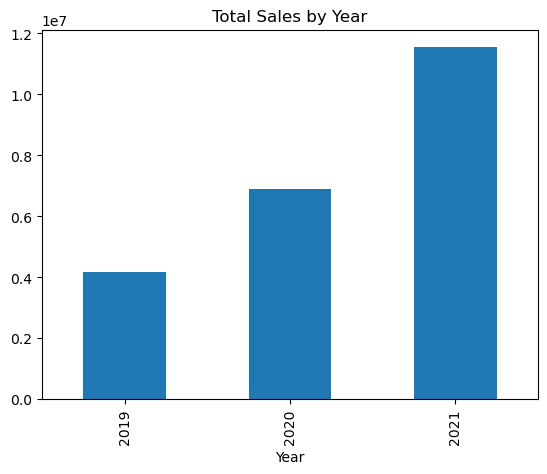

In [3]:
import matplotlib.pyplot as plt

df_fact = spark.read.table("dbo.factsales_gold").toPandas()
yearly_sales = df_fact.groupby("Year")["TotalAmount"].sum()

yearly_sales.plot(kind="bar", title="Total Sales by Year")
plt.show()